# Optotagging Parameter Tuning

Focused notebook for finding optimal classification thresholds for Cre+ neurons.
Uses the `visb_analysis` package for code imports.

**Workflow:**
1. Pick a session (Sst or Vip) in the session cell
2. Change parameters in the PARAMETERS cell
3. Re-run cells to see the effect on Cre+ count, scatter, and heatmaps
4. Record the parameters in the appropriate config file
5. Run `all_session_analysis.ipynb` notebook with the proper config file for a full session analysis of chosen parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', category=UserWarning, module='hdmf')

from visb_analysis import SessionHandler, UnitCollection
from visb_analysis.psth import make_population_psth
from visb_analysis.optotagging import (
    get_opto_rates,
    compute_trial_reliability,
    compute_spike_latency,
    compute_shuffled_fp_rate,
)
from visb_analysis.plots import (
    plot_opto_scatter,
    plot_opto_heatmaps,
    plot_multi_session_scatter,
    plot_multi_session_counts,
    plot_reliability_histogram,
    plot_latency_histogram,
    plot_fp_summary,
)

## 1. Load Session

Change `GENOTYPE` to `"Sst"` or `"Vip"` to switch between cell types.  
Change `SESSION_INDEX` to try a different representative session (0 = first available).

In [11]:
config_path = Path('../configs/base.yaml')
with config_path.open('r') as f:
    config = yaml.safe_load(f)

session_handler = SessionHandler(Path(config['cache_dir']))
session_table = session_handler.session_table

# Define chosen genotype and session
GENOTYPE = 'Sst'       # 'Sst' or 'Vip'
SESSION_INDEX = 0      # index into the filtered list

filtered = session_table[
    session_table['genotype'].str.contains(GENOTYPE) &
    (session_table['experience_level'] == 'Novel')
]
session_id = filtered.index[SESSION_INDEX]
# Or define as such:
# session_id = 1048196054  
session_id = 1048196054  

session = session_handler.cache.get_ecephys_session(session_id)

row = filtered.loc[session_id]
print(f'Session ID : {session_id}')
print(f'Genotype : {row["genotype"]}')
print(f'Experience : {row["experience_level"]}')
print(f'Total sessions available for {GENOTYPE}: {len(filtered)}')

Session ID : 1048196054
Genotype : Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
Experience : Novel
Total sessions available for Sst: 21


## 2. Filter Units

Region filter is set here in the notebook — tuning is focused on visual cortex.
Unit quality filters come from `configs/base.yaml` and are shared with `run_all_sessions.py`.

In [12]:
# Regions to focus on for parameter tuning — visual cortex only.
# run_all_sessions.py processes all regions; this is tuning-specific.
REGIONS = ['VIS']

units = (
    UnitCollection(session=session)
    .filter_quality(config['unit_filters'])
    .filter_region(REGIONS)
)
print(f"Unit filters : {config['unit_filters']}")
print(f"Regions      : {REGIONS}  (tuning focus — not used by run_all_sessions.py)")
print(f"Units        : {len(units)}")

Unit filters : {'snr_min': 1.0, 'isi_violations_max': 1.0, 'firing_rate_min': 0.1, 'quality': 'good'}
Regions      : ['VIS']  (tuning focus — not used by run_all_sessions.py)
Units        : 424


## 3. Build Opto Array

Selects the short, max-power laser pulses and builds a 3D array:  
`opto_array` shape: **(neurons × time_bins × trials)**

Uses `make_population_psth` with the opto pulse times as trial events.  
Time axis runs from -50ms to +100ms around each laser onset.

In [13]:
opto_table = session.optotagging_table

# Short pulses at maximum power level
sel_pulses = opto_table[
    (opto_table['duration'] <= config['optotagging']['max_pulse_duration']) &
    (opto_table['level'] == opto_table['level'].max())
]
pulse_times = sel_pulses['start_time'].values
print(f'Selected pulses: {len(pulse_times)}')

TIME_BEFORE = config['psth']['time_before']
DURATION    = config['psth']['duration']
BIN_SIZE    = config['psth']['bin_size']

opto_array, time_bins, unit_ids = make_population_psth(
    units, pulse_times, TIME_BEFORE, DURATION, BIN_SIZE
)
print(f'opto_array shape: {opto_array.shape}  (neurons x time_bins x trials)')

Selected pulses: 50
opto_array shape: (424, 1500, 50)  (neurons x time_bins x trials)


## 4. PARAMETERS

These are the main parameters to change, once happy with results, save parameters in a config file for further analysis on all sessions.

| Parameter | Description |
|---|---|
| `increase_in_FR` | Fold-change: evoked rate must be this many times the baseline rate |
| `min_evoked_rate` | Minimum absolute evoked firing rate (Hz) to guard against low-rate flukes |
| `evoked_start_ms` | Start of evoked window in ms after laser onset |
| `evoked_end_ms` | End of evoked window in ms after laser onset |

In [20]:
# fold-change threshold
increase_in_FR = 2 
# minimum Hz
min_evoked_rate = 30
# ms after laser onset
evoked_start_ms = 1
# ms after laser onset
evoked_end_ms = 9

# Baseline window is fixed: -10ms to -2ms before laser
baseline_idx = (time_bins >= -0.010) & (time_bins < -0.002)
evoked_idx = (time_bins >= evoked_start_ms / 1000) & (time_bins < evoked_end_ms / 1000)

# Mean response across trials for each neuron
mean_opto = np.nanmean(opto_array, axis=2) # (neurons, time_bins)

# Calculate Spikes / Seconds (Hz)
baseline_rate = np.mean(mean_opto[:, baseline_idx], axis=1)
evoked_rate = np.mean(mean_opto[:, evoked_idx], axis=1)

# Classify from chosen parameters
cre_pos_idx = (
    (evoked_rate > min_evoked_rate) &
    ((evoked_rate / (baseline_rate + 1)) > increase_in_FR)
)

n_total = len(units)
n_pos = int(cre_pos_idx.sum())
n_neg = n_total - n_pos
print(f'Parameters  ->  fold={increase_in_FR}x  |  min_rate={min_evoked_rate} Hz  |  window={evoked_start_ms}-{evoked_end_ms} ms')
print(f'Total units : {n_total}')
print(f'Cre+        : {n_pos}  ({100 * n_pos / n_total:.1f}%)')
print(f'Cre-        : {n_neg}  ({100 * n_neg / n_total:.1f}%)')

Parameters  ->  fold=2x  |  min_rate=30 Hz  |  window=1-9 ms
Total units : 424
Cre+        : 0  (0.0%)
Cre-        : 424  (100.0%)


## 5. Scatter Plot of Baseline vs Evoked Rate

-> Red dashed line = fold-change threshold

-> Blue dashed line = minimum evoked rate.  

Cre+ cells (red) should be above both lines with no borderlin cases

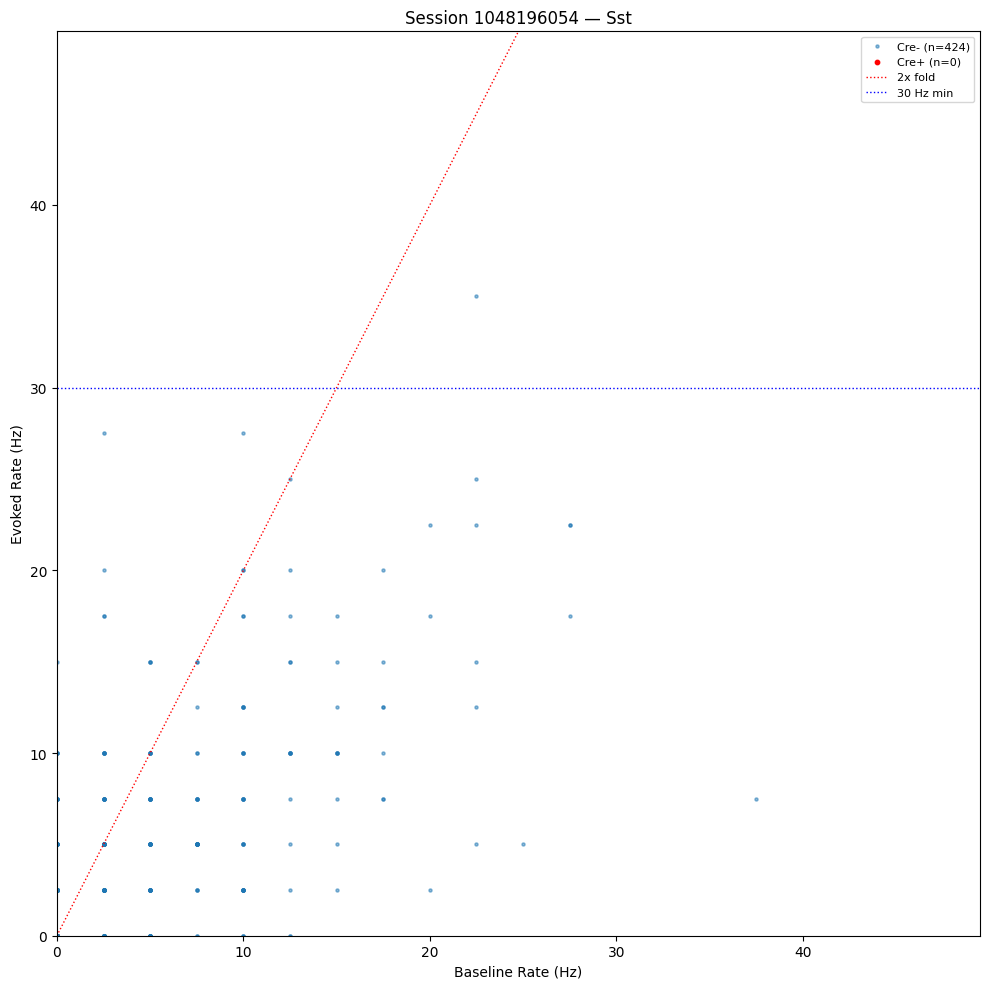

In [21]:
fig = plot_opto_scatter(
    baseline_rate, evoked_rate, cre_pos_idx,
    increase_in_FR, min_evoked_rate,
    session_id=session_id, genotype=GENOTYPE,
    figsize = (10, 10)
)
plt.show()

## 6. Heatmap of Cre+ and Cre- Responses

Cyan dotted lines mark the evoked window boundaries.  

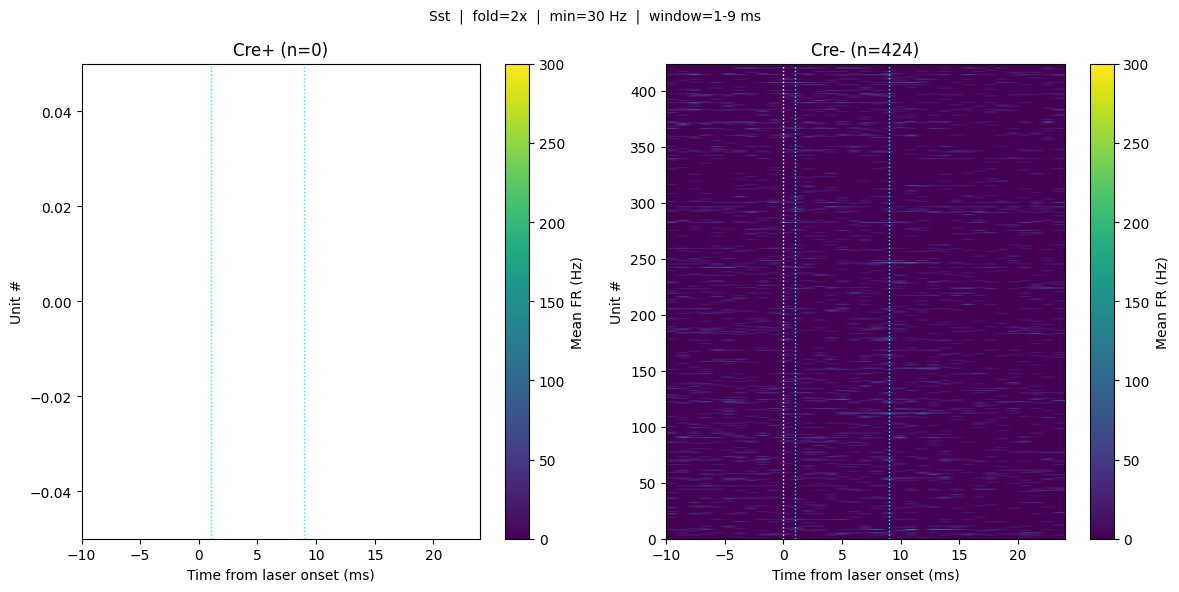

In [22]:
fig = plot_opto_heatmaps(
    mean_opto, cre_pos_idx, time_bins,
    evoked_start_ms, evoked_end_ms,
    increase_in_FR, min_evoked_rate, genotype=GENOTYPE,
)
plt.show()

## 7. Multi-Session Parameter Check

Runs the current parameters across a few sessions for the chosen genotype.

**Workflow:**
- Run **"Load into cache"** once (or when you change `num_sessions` / `GENOTYPE`)
- Run **"Apply parameters"** freely — it reads from the cache, no reloading

### Load into cache (run once)

In [8]:
# how many sessions to check, you can adjust this if you don't want to cache all filtered sessions
# num_sessions = filtered.index.size
num_sessions = 3

if '_ms_cache' not in dir():
    _ms_cache = {}

print(f'Loading {num_sessions} {GENOTYPE} sessions into cache...')
for sid in filtered.index[:num_sessions]:
    if sid in _ms_cache:
        print(f'  {sid}  [already cached, skipping]')
        continue
    sess = session_handler.cache.get_ecephys_session(sid)
    units_s = (
        UnitCollection(session=sess)
        .filter_quality(config['unit_filters'])
        .filter_region(REGIONS)
    )
    baseline_s, evoked_s, _ = get_opto_rates(units_s, sess, config['optotagging'])
    _ms_cache[sid] = {
        'baseline_rates': baseline_s,
        'evoked_rates':   evoked_s,
        'n_units':        len(units_s),
        # stored for Section 9 shuffled FP control
        'spike_times':    units_s.get_spike_times(),
        'unit_ids':       list(units_s.units.index),
    }
    print(f'  {sid}  units={len(units_s)}  [loaded]')

print(f'Cache holds {len(_ms_cache)} session(s). Re-run "Apply parameters" to update plots.')

Loading 3 Sst sessions into cache...
  1048189115  units=472  [loaded]
  1048196054  units=424  [loaded]
  1053941483  units=368  [loaded]
Cache holds 3 session(s). Re-run "Apply parameters" to update plots.


### Apply parameters to sessions in cache

  1048189115  units=472  Cre+=45
  1048196054  units=424  Cre+=0
  1053941483  units=368  Cre+=39


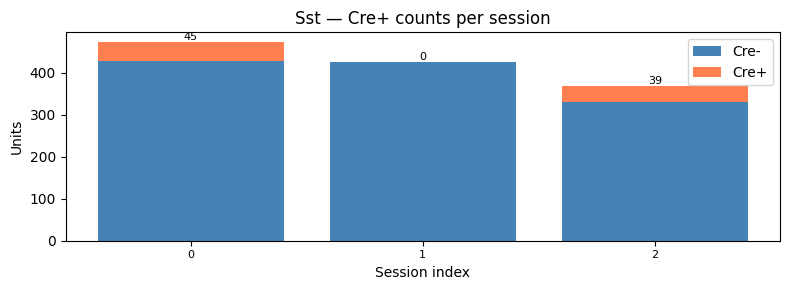

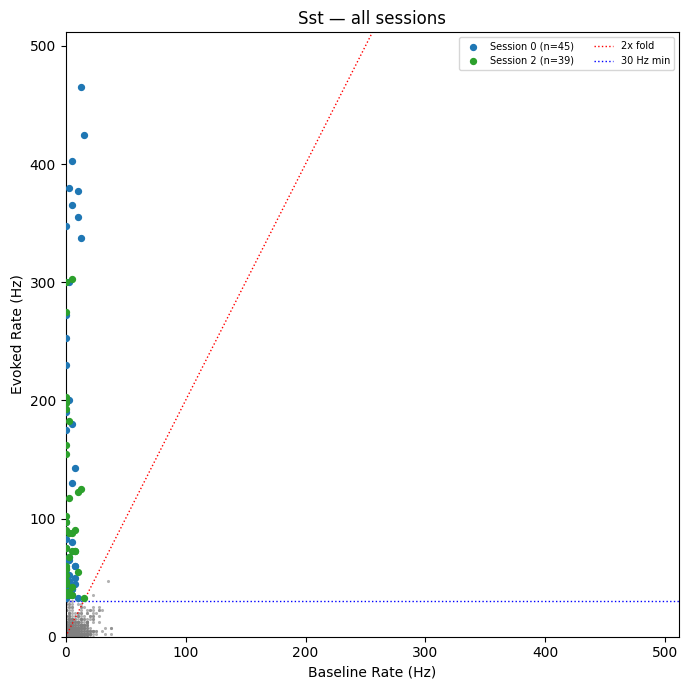

In [23]:
# fold-change threshold
increase_in_FR = 2
# minimum Hz
min_evoked_rate = 30


session_results = []
for sid, data in _ms_cache.items():
    baseline_s = data['baseline_rates']
    evoked_s   = data['evoked_rates']
    cre_pos_s  = (
        (evoked_s > min_evoked_rate) &
        ((evoked_s / (baseline_s + 1)) > increase_in_FR)
    )
    session_results.append({
        'session_id':    sid,
        'baseline_rates': baseline_s,
        'evoked_rates':   evoked_s,
        'cre_pos_mask':   cre_pos_s,
    })
    print(f'  {sid}  units={data["n_units"]}  Cre+={int(cre_pos_s.sum())}')


fig = plot_multi_session_counts(session_results, genotype=GENOTYPE)
plt.show()
fig = plot_multi_session_scatter(session_results, increase_in_FR, min_evoked_rate, genotype=GENOTYPE)
plt.show()

## 8. Trial Reliability & First-Spike Latency

Diagnostic quality metrics for the current Cre+ classification. These do **not** add new classification criteria — they reveal whether Cre+ units are genuinely and consistently driven by the laser.

| Metric | What to look for |
|---|---|
| **Trial reliability** | Fraction of opto trials with ≥1 spike in the evoked window. Well-driven SST/VIP units should respond on >50–60% of trials. |
| **First-spike latency** | Average earliest spike time per trial (ms). ChR2-driven spikes appear at ~2–4 ms. Units classified mostly from late spikes (>7 ms) within the 1–9 ms window are less convincing. |

Reuses `units` and `pulse_times` from Sections 2–3.

In [24]:
evoked_window = config['optotagging']['evoked_window']

reliability, _ = compute_trial_reliability(units, pulse_times, evoked_window)
latency_ms, _  = compute_spike_latency(units, pulse_times, evoked_window)

n_cre_pos = int(cre_pos_idx.sum())
if n_cre_pos > 0:
    med_rel  = np.nanmedian(reliability[cre_pos_idx])
    frac_above = (reliability[cre_pos_idx] > 0.5).mean()
    med_lat  = np.nanmedian(latency_ms[cre_pos_idx])
    print(f'Cre+ units              : {n_cre_pos}')
    print(f'Median trial reliability: {med_rel:.2f}  (fraction of trials with ≥1 spike)')
    print(f'Fraction with rel > 0.5 : {frac_above:.2f}')
    print(f'Median first-spike lat  : {med_lat:.2f} ms')
else:
    print('No Cre+ units under current parameters.')

No Cre+ units under current parameters.


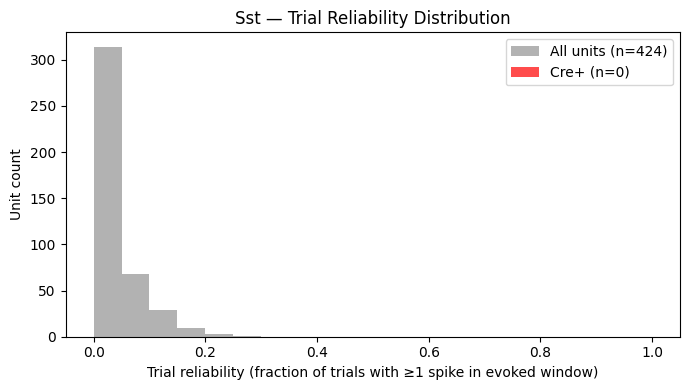

In [25]:
fig = plot_reliability_histogram(reliability, cre_pos_idx, genotype=GENOTYPE)
plt.show()

C:\Users\Jacob Poschl\Desktop\visb_ecephys_analysis\visb_analysis\plots.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


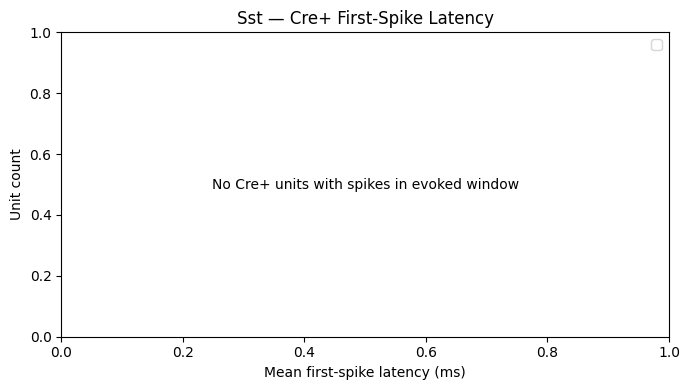

In [26]:
fig = plot_latency_histogram(latency_ms, cre_pos_idx, genotype=GENOTYPE)
plt.show()

## 9. Shuffled Control — False Positive Rate Estimate

Estimates the false positive (FP) rate by time-shifting all laser pulse onsets by fixed offsets (+5 s, +10 s, … +100 s) and re-running classification on these "fake" trials. Units classified as Cre+ under shifted pulses are almost certainly false positives driven by coincidental spiking activity.

**Single session** uses `units` and `pulse_times` from Sections 2–3.  
**Multi-session** uses `_ms_cache` from Section 7 (requires the cache to have been built or re-run after the `spike_times` key was added).

In [ ]:
### Single-session shuffled control

fp_counts_single, n_units_single = compute_shuffled_fp_rate(
    units.get_spike_times(),
    list(units.units.index),
    pulse_times,
    config['optotagging'],
    increase_in_FR,
    min_evoked_rate,
    n_shuffles=20,
    shift_s=5.0,
)

mean_fp_single = np.mean(fp_counts_single)
std_fp_single  = np.std(fp_counts_single)
true_cre_pos   = int(cre_pos_idx.sum())

print(f'True Cre+ count       : {true_cre_pos}')
print(f'Shuffled FP (mean±std): {mean_fp_single:.1f} ± {std_fp_single:.1f}')
print(f'FP rate estimate      : {mean_fp_single / n_units_single:.4f}')
print(f'Shuffle counts        : {fp_counts_single}')

In [ ]:
### Multi-session shuffled control (requires Section 7 cache with spike_times)

if '_ms_cache' not in dir():
    print("Section 7 cache not found. Run the cache-load cell in Section 7 first.")
elif 'spike_times' not in next(iter(_ms_cache.values())):
    print("Cache is missing 'spike_times'. Re-run the Section 7 cache-load cell to rebuild.")
else:
    ms_session_results = []
    ms_fp_rates = []

    for i, (sid, data) in enumerate(_ms_cache.items()):
        # Re-apply current parameters from cached rates
        cre_pos_s = (
            (data['evoked_rates'] > min_evoked_rate) &
            ((data['evoked_rates'] / (data['baseline_rates'] + 1)) > increase_in_FR)
        )
        ms_session_results.append({
            'session_id':    sid,
            'baseline_rates': data['baseline_rates'],
            'evoked_rates':   data['evoked_rates'],
            'cre_pos_mask':   cre_pos_s,
        })

        # Shuffled control using cached spike times
        # Note: uses the current session's pulse_times as a proxy for all sessions
        # (valid — Allen optotagging protocol is fixed within genotype/experience)
        fp_counts_s, _ = compute_shuffled_fp_rate(
            data['spike_times'],
            data['unit_ids'],
            pulse_times,
            config['optotagging'],
            increase_in_FR,
            min_evoked_rate,
            n_shuffles=20,
            shift_s=5.0,
        )
        ms_fp_rates.append({
            'session_id': sid,
            'mean_fp':    np.mean(fp_counts_s),
            'std_fp':     np.std(fp_counts_s),
        })
        print(f'  Session {i} ({sid}): Cre+={int(cre_pos_s.sum())}  '
              f'FP_mean={np.mean(fp_counts_s):.1f} ± {np.std(fp_counts_s):.1f}')

    fig = plot_fp_summary(ms_session_results, ms_fp_rates, genotype=GENOTYPE)
    plt.show()

## 10. Wild-Type Control — False Positive Check

Applies the current parameters to **wild-type (`wt/wt`) sessions** — animals with no Cre driver and no ChR2. Any units classified as Cre+ here are definitively false positives driven by coincidental spiking, not genuine light-driven responses.

A well-tuned parameter set should produce near-zero Cre+ counts across all WT sessions.

Change `n_control_sessions` to test more or fewer WT sessions.

In [ ]:
n_control_sessions = 5

wt_filtered = session_table[
    (session_table['genotype'] == 'wt/wt') &
    (session_table['experience_level'] == 'Novel')
]

n_to_load = min(n_control_sessions, len(wt_filtered))
print(f'Found {len(wt_filtered)} wt/wt Novel sessions. Loading {n_to_load}...')

if len(wt_filtered) == 0:
    print("No wild-type sessions found. Check session_table['genotype'].unique().")
    control_results = []
else:
    control_results = []
    for sid in wt_filtered.index[:n_to_load]:
        sess_ctrl = session_handler.cache.get_ecephys_session(sid)
        units_ctrl = (
            UnitCollection(session=sess_ctrl)
            .filter_quality(config['unit_filters'])
            .filter_region(REGIONS)
        )
        baseline_c, evoked_c, _ = get_opto_rates(units_ctrl, sess_ctrl, config['optotagging'])
        cre_pos_c = (
            (evoked_c > min_evoked_rate) &
            ((evoked_c / (baseline_c + 1)) > increase_in_FR)
        )
        control_results.append({
            'session_id':    sid,
            'baseline_rates': baseline_c,
            'evoked_rates':   evoked_c,
            'cre_pos_mask':   cre_pos_c,
        })
        print(f'  {sid}  units={len(units_ctrl)}  FP={int(cre_pos_c.sum())}')

    total_wt_units = sum(len(r['baseline_rates']) for r in control_results)
    total_wt_pos   = sum(int(r['cre_pos_mask'].sum()) for r in control_results)
    fp_rate_wt     = total_wt_pos / total_wt_units if total_wt_units > 0 else 0.0
    print(f'\nWT false positive rate: {total_wt_pos}/{total_wt_units} = {fp_rate_wt:.4f}')

In [ ]:
if control_results:
    fig = plot_multi_session_counts(control_results, genotype='wt/wt (no ChR2)')
    plt.show()
    fig = plot_multi_session_scatter(
        control_results, increase_in_FR, min_evoked_rate,
        genotype=f'wt/wt — {GENOTYPE} thresholds applied',
    )
    plt.show()